# Module 1 · Take-Home Lab — Multi-Modal Prompt Engineering Workflow
## Text + Image + Video + Audio — Complete Campaign Asset Pipeline

---

### Lab Overview

Modern marketing teams need **complete multi-format campaign packages** — text copy, hero images, short-form video, and audio narrations — all from a single creative brief. This lab chains **four GenAI modalities** into an automated pipeline:

```
📝 Product Brief (LLM)  →  🎨 Hero Image (Image Gen)  →  🎬 Promo Video (Sora)  →  🔊 Voiceover (TTS)  →  📦 Final Video + VO
```

| Step | Modality | API / Model | Output |
|------|----------|-------------|--------|
| 1. Product Brief | **Text generation** | `gpt-4.1-mini` | Marketing copy |
| 2. Image Prompt | **Prompt chaining** | `gpt-4.1-mini` → optimized image prompt | — |
| 3. Visual Creative | **Image generation** | `gpt-image-1.5` | Hero image (PNG) |
| 4. Video Prompt | **Prompt chaining** | `gpt-4.1-mini` → optimized video prompt | — |
| 5. Promo Video | **Video generation** | `sora-2` | MP4 clip (4-12 sec) |
| 6. Voiceover Script | **Text generation** | `gpt-4.1-mini` | Ad script |
| 7. Audio Narration | **Text-to-speech** | `gpt-4o-mini-tts` | MP3 voiceover |
| 8. Merge (Bonus) | **ffmpeg** | Video + Audio → final clip | MP4 with VO |

### Learning Objectives

1. Chain **four GenAI modalities** (text → image → video → audio) into a cohesive workflow
2. Use LLMs to generate optimized prompts for image and video models (**prompt chaining**)
3. Work with OpenAI's **Sora Video API** — an asynchronous job-based API with polling
4. Produce a complete marketing asset package from a single business brief
5. Combine video + voiceover audio into a final deliverable using ffmpeg

> **⚠️ Note:** The Sora Video API is in **preview**. You may need [API Organization Verification](https://help.openai.com/en/articles/10910291-api-organization-verification) enabled. Video generation is async and takes **1-5 minutes** per clip.

---

> 🏠 **Take-home reference lab.** Not run in the workshop sessions — work through it afterwards at your own pace. Its API keys are yours to create (see the workshop's `README.md`).

> 🏦 **Start with the bank's campaign.** Scenario 3 (§7) is the retail-bank savings-account
> campaign. Run §1–4 first: Scenario 1 is the step-by-step walkthrough, and it defines the helper
> functions every later scenario — Scenario 3 included — reuses.
>
> The same prompting patterns from Lab 1.1 apply here; the difference is the *output*. Every image,
> video and voiceover is steered by a prompt that an LLM writes first — **prompt chaining**.
>
> 🎬 **Video needs access.** Sora video generation requires video-API access on your own OpenAI
> organisation and costs noticeably more than the other steps. The stored outputs show what each video
> cell produces; skip those cells if your key does not have access.

## 1. Install Dependencies

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU openai requests Pillow imageio-ffmpeg

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "openai",
    "requests",
    "Pillow",
    "imageio-ffmpeg",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

openai                     2.54.0
requests                   2.34.2
Pillow                     12.3.0
imageio-ffmpeg             0.6.0


## 2. API Key Configuration

> **Setup:** on the workshop VM the key is already in the workshop's `.env` file. On Colab, add `OPENAI_API_KEY` in the 🔑 Secrets panel and toggle "Notebook access" on.

This lab uses only OpenAI APIs — text, image, video, and audio all use the same API key.

In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)


load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## 3. Initialize Client & Define Helper Functions

In [3]:
import time
import json
import base64
import subprocess
import requests
from pathlib import Path
from io import BytesIO
from openai import OpenAI
from PIL import Image
from IPython.display import display, Audio, HTML

client = OpenAI()

# API base + auth header for Sora REST calls
API_BASE = "https://api.openai.com/v1"
AUTH_HEADERS = {
    "Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}",
    "Content-Type": "application/json"
}

print("OpenAI client initialized ✅")

# ffmpeg merges video and voiceover. Colab ships it; on Windows it is usually not on PATH,
# so fall back to the copy the imageio-ffmpeg package bundles.
import shutil
import imageio_ffmpeg

FFMPEG_EXECUTABLE = shutil.which("ffmpeg") or imageio_ffmpeg.get_ffmpeg_exe()
print(f"ffmpeg: {FFMPEG_EXECUTABLE}")

OpenAI client initialized ✅
ffmpeg: C:\Users\participant\.venvs\workshop\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [4]:
# ═══════════════════════════════════════════════════════════
# CORE GENERATION FUNCTIONS — Text, Image, Video, Audio
# ═══════════════════════════════════════════════════════════

# --- TEXT GENERATION ---
def generate_text(system_prompt, user_prompt, model="gpt-4.1-mini", temperature=0.7):
    """Generate text using an LLM. Returns the text and latency."""
    start = time.time()
    response = client.chat.completions.create(
        model=model,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    latency = round(time.time() - start, 2)
    return response.choices[0].message.content, latency


# --- IMAGE GENERATION (GPT Image 1.5) ---
def generate_image(prompt, size="1024x1024", quality="medium"):
    """Generate an image using GPT Image 1.5. Returns PIL image and metadata."""
    start = time.time()
    response = client.images.generate(
        model="gpt-image-1.5",
        prompt=prompt,
        size=size,
        quality=quality,
        n=1
    )
    latency = round(time.time() - start, 2)

    # GPT Image returns base64-encoded data
    image_b64 = response.data[0].b64_json
    pil_image = Image.open(BytesIO(base64.b64decode(image_b64)))

    return {
        "image": pil_image,
        "revised_prompt": getattr(response.data[0], 'revised_prompt', None),
        "latency_sec": latency
    }


def save_and_show_image(image_result, filepath="hero_image.png", max_width=512):
    """Save a PIL image to disk and display it in the notebook."""
    image_result["image"].save(filepath)
    thumbnail_image = image_result["image"].copy()
    thumbnail_image.thumbnail((max_width, max_width))
    display(thumbnail_image)
    print(f"   💾 Saved to {filepath}")


# --- VIDEO GENERATION (Sora 2) ---
def create_video_job(prompt, model="sora-2", seconds="8", size="1280x720"):
    """
    Start a Sora video generation job (async).
    Returns the job metadata dict with id and status.
    """
    payload = {
        "prompt": prompt,
        "model": model,
        "seconds": str(seconds),
        "size": size
    }
    http_response = requests.post(f"{API_BASE}/videos", headers=AUTH_HEADERS, json=payload)
    http_response.raise_for_status()
    return http_response.json()


def poll_video_status(video_id, poll_interval=15, max_wait=600):
    """
    Poll the Sora API until a video job completes or fails.
    Returns the final job metadata dict.
    """
    headers = {"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"}
    start = time.time()
    while True:
        http_response = requests.get(f"{API_BASE}/videos/{video_id}", headers=headers)
        http_response.raise_for_status()
        video_job = http_response.json()
        status = video_job.get("status", "unknown")
        progress = video_job.get("progress", 0)
        elapsed = round(time.time() - start)

        print(f"   ⏳ [{elapsed}s] Status: {status} | Progress: {progress}%")

        if status == "completed":
            return video_job
        elif status == "failed":
            error = video_job.get("error", {})
            raise Exception(f"Video generation failed: {error.get('message', 'Unknown error')}")

        if time.time() - start > max_wait:
            raise TimeoutError(f"Video job {video_id} did not complete within {max_wait}s")

        time.sleep(poll_interval)


def download_video(video_id, output_path="video.mp4"):
    """Download a completed video as MP4."""
    headers = {"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"}
    http_response = requests.get(
        f"{API_BASE}/videos/{video_id}/content",
        headers=headers,
        params={"variant": "video"},
        stream=True
    )
    http_response.raise_for_status()
    with open(output_path, "wb") as output_file:
        for chunk in http_response.iter_content(chunk_size=8192):
            output_file.write(chunk)
    size_mb = Path(output_path).stat().st_size / (1024 * 1024)
    return {"path": output_path, "size_mb": round(size_mb, 2)}


def generate_video(prompt, model="sora-2", seconds="8", size="1280x720",
                    output_path="video.mp4"):
    """
    Full video generation workflow: create job → poll → download MP4.
    Returns dict with path, size, job metadata, and total latency.
    """
    start = time.time()

    # Step 1: Start the job
    print(f"   🚀 Starting Sora video job ({model}, {seconds}s, {size})...")
    video_job = create_video_job(prompt, model=model, seconds=seconds, size=size)
    video_id = video_job["id"]
    print(f"   📋 Job ID: {video_id}")

    # Step 2: Poll until complete
    print("   ⏳ Waiting for generation (this may take 1-5 minutes)...")
    final_job = poll_video_status(video_id)

    # Step 3: Download the MP4
    print("   📥 Downloading MP4...")
    download_result = download_video(video_id, output_path)

    total_latency = round(time.time() - start, 2)
    return {
        "path": download_result["path"],
        "size_mb": download_result["size_mb"],
        "video_id": video_id,
        "latency_sec": total_latency,
        "prompt": prompt
    }


# --- AUDIO GENERATION (TTS) ---
def generate_audio(text, voice="nova", instructions="", output_path="output.mp3"):
    """Generate speech from text using gpt-4o-mini-tts. Saves to file and returns metadata."""
    start = time.time()
    kwargs = {
        "model": "gpt-4o-mini-tts",
        "voice": voice,
        "input": text,
        "response_format": "mp3"
    }
    if instructions:
        kwargs["instructions"] = instructions

    with client.audio.speech.with_streaming_response.create(**kwargs) as response:
        response.stream_to_file(output_path)

    latency = round(time.time() - start, 2)
    file_size_kb = Path(output_path).stat().st_size / 1024
    return {"path": output_path, "size_kb": round(file_size_kb, 1), "latency_sec": latency}


# --- VIDEO + AUDIO MERGE ---
def merge_video_audio(video_path, audio_path, output_path="final_video.mp4"):
    """
    Merge a video file with an audio track using ffmpeg.
    Audio is trimmed/padded to match video duration.
    """
    start = time.time()
    ffmpeg_command = [
        FFMPEG_EXECUTABLE, "-y",
        "-i", video_path,       # Video input
        "-i", audio_path,       # Audio input
        "-c:v", "copy",         # Copy video stream (no re-encode)
        "-c:a", "aac",          # Encode audio to AAC
        "-b:a", "128k",         # Audio bitrate
        "-shortest",            # Trim to shorter of video/audio
        "-movflags", "+faststart",
        output_path
    ]
    result = subprocess.run(ffmpeg_command, capture_output=True, text=True)
    if result.returncode != 0:
        raise Exception(f"ffmpeg error: {result.stderr}")

    latency = round(time.time() - start, 2)
    size_mb = Path(output_path).stat().st_size / (1024 * 1024)
    return {"path": output_path, "size_mb": round(size_mb, 2), "latency_sec": latency}

print("All helper functions defined ✅")
print("  📝 generate_text()  — LLM text generation")
print("  🎨 generate_image() — GPT Image 1.5")
print("  🎬 generate_video() — Sora 2 (async job + poll + download)")
print("  🔊 generate_audio() — gpt-4o-mini-tts")
print("  🔗 merge_video_audio() — ffmpeg video+audio merge")

All helper functions defined ✅
  📝 generate_text()  — LLM text generation
  🎨 generate_image() — GPT Image 1.5
  🎬 generate_video() — Sora 2 (async job + poll + download)
  🔊 generate_audio() — gpt-4o-mini-tts
  🔗 merge_video_audio() — ffmpeg video+audio merge


## 4. Scenario 1 — E-Commerce Product Launch Campaign (Step-by-Step)

### Business Context
An online wellness brand is launching a **premium herbal tea collection**. The marketing team needs a complete campaign package for Instagram:
1. **Product brief** — positioning, key messages, target audience
2. **Hero image** — lifestyle product photo for the Instagram feed
3. **Promo video** — 8-second product reveal clip for Reels
4. **Voiceover** — narration for the video ad
5. **Final video** — merged video + voiceover

We'll walk through each step individually, then later wrap it all into a reusable pipeline.

### Step 1: Generate the Product Brief (Text)

In [5]:
# --- Step 1: Generate a product brief from a business description ---
business_input = """
Product: "Serenity Blends" — a premium herbal tea collection
- 4 flavors: Chamomile Dream, Lavender Calm, Mint Refresh, Ginger Glow
- Organic, sustainably sourced, packaged in compostable sachets
- Price: $24.99 for a sampler box of 20 sachets
- Target: Health-conscious millennials and Gen-Z, ages 25-40
- Launch channel: Instagram (feed + Reels + Stories)
"""

brief, brief_latency = generate_text(
    system_prompt="""You are a senior marketing strategist. Generate a concise product brief
with these sections: Positioning Statement, Key Messages (3 bullets), Target Audience Profile,
Suggested Campaign Tagline. Keep it under 200 words.""",
    user_prompt=f"Create a product brief for this launch:\n{business_input}",
    temperature=0.7
)

print(f"⏱️ Brief generated in {brief_latency}s\n")
print(brief)

⏱️ Brief generated in 2.25s

**Positioning Statement:**  
Serenity Blends offers a premium, organic herbal tea collection designed to elevate daily wellness rituals through sustainably sourced, calming flavors—perfect for health-conscious millennials and Gen-Z seeking natural balance in a hectic world.

**Key Messages:**  
- Crafted from 100% organic, sustainably harvested herbs for pure, authentic flavors.  
- Packaged in eco-friendly, compostable sachets to support a greener planet.  
- A curated sampler box featuring four unique blends to promote relaxation, refreshment, and vitality.

**Target Audience Profile:**  
Millennials and Gen-Z adults aged 25-40 who prioritize health, sustainability, and mindful living. They value natural products that support wellness and environmental responsibility, and actively engage with lifestyle content on Instagram.

**Suggested Campaign Tagline:**  
“Sip Serenity. Live Mindfully.”


### Step 2: Generate an Optimized Image Prompt (Prompt Chaining)

In [6]:
# --- Step 2: Use the LLM to craft an optimized image prompt from the brief ---
# This is "prompt chaining" — using one LLM output to create input for another model

image_prompt, prompt_latency = generate_text(
    system_prompt="""You are an expert at writing image generation prompts for OpenAI's GPT Image model.
Given a product brief, write a single detailed image prompt for a lifestyle product photo.
Include: subject, setting, lighting, color palette, style, and composition.
The image should feel premium and Instagram-worthy.
Return ONLY the image prompt text, nothing else.""",
    user_prompt=f"Write an image generation prompt for this product:\n{brief}",
    temperature=0.8
)

print(f"⏱️ Image prompt generated in {prompt_latency}s\n")
print(f"🎨 Generated image prompt:\n{image_prompt}")

⏱️ Image prompt generated in 1.71s

🎨 Generated image prompt:
A premium lifestyle product photo featuring a curated sampler box of Serenity Blends organic herbal teas displayed on a minimalist wooden table by a sunlit window. The scene includes four eco-friendly, compostable sachets artfully arranged beside delicate ceramic teacups filled with steaming tea, wisps of steam gently rising. Surrounding elements: fresh green herbs, a linen napkin, and a small potted succulent, emphasizing natural and sustainable living. Soft, natural morning light floods the space, casting warm, inviting shadows. The color palette blends earthy greens, warm neutrals, and soft whites, creating a calm, serene atmosphere. Composition is clean and balanced, shot from a slightly elevated angle to showcase the packaging and tea simultaneously. The style is modern, organic, and Instagram-worthy, evoking wellness, mindfulness, and eco-conscious elegance.


### Step 3: Generate the Visual Creative (Image)

🎨 Generating hero image with GPT Image 1.5...


⏱️ Image generated in 16.52s



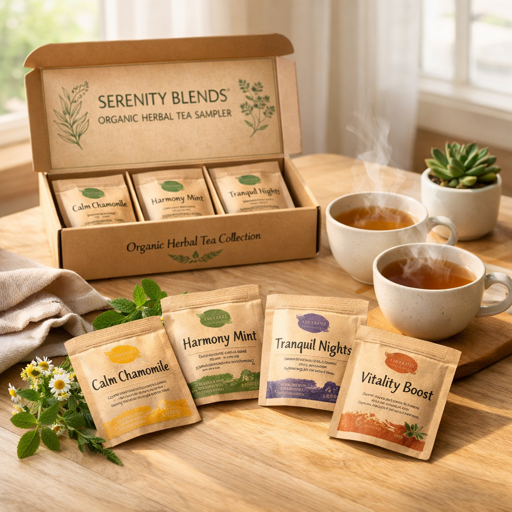

   💾 Saved to ecommerce_hero.png


In [7]:
# --- Step 3: Generate the hero image using GPT Image 1.5 ---
print("🎨 Generating hero image with GPT Image 1.5...")

image_result = generate_image(
    prompt=image_prompt,
    size="1024x1024",     # Square for Instagram feed
    quality="medium"
)

print(f"⏱️ Image generated in {image_result['latency_sec']}s")
if image_result.get("revised_prompt"):
    print(f"📝 Revised prompt: {image_result['revised_prompt'][:150]}...")
print()
save_and_show_image(image_result, filepath="ecommerce_hero.png")

### Step 4: Generate the Promo Video (Sora 2)

Now for the new modality — **video generation with Sora**.

The Sora API is **asynchronous**:
1. `POST /videos` — submits a render job → returns a job ID
2. `GET /videos/{id}` — poll until `status == "completed"` (typically 1-5 min)
3. `GET /videos/{id}/content` — download the final MP4

Our `generate_video()` helper wraps all three steps.

In [8]:
# --- Step 4a: Generate an optimized video prompt from the brief ---
video_prompt, video_prompt_latency = generate_text(
    system_prompt="""You are an expert at writing video generation prompts for OpenAI's Sora model.
Given a product brief, write a single detailed video prompt for an 8-second product reveal clip.
Describe: shot type, subject, action/motion, setting, lighting, camera movement, and mood.
Sora works best with specific cinematic descriptions.
Return ONLY the video prompt text, nothing else.""",
    user_prompt=f"Write a Sora video prompt for an 8-second Instagram Reel ad for this product:\n{brief}",
    temperature=0.8
)

print(f"⏱️ Video prompt generated in {video_prompt_latency}s\n")
print(f"🎬 Generated video prompt:\n{video_prompt}")

⏱️ Video prompt generated in 1.27s

🎬 Generated video prompt:
A warm close-up shot of a hand gently lifting a compostable sachet from an elegantly designed Serenity Blends sampler box on a wooden table bathed in soft morning light; the camera slowly dollies out and tilts up to reveal a steaming, translucent teacup surrounded by fresh herbs and green leaves, while a subtle breeze moves sheer curtains in a sunlit, minimalist kitchen, creating a calm, inviting atmosphere that embodies natural balance and mindful living.


In [9]:
# --- Step 4b: Generate the video using Sora 2 ---
# ⚠️ This will take 1-5 minutes. The cell polls automatically and prints progress.
print("🎬 Generating promo video with Sora 2...")
print("   (This typically takes 1-5 minutes — grab a coffee ☕)\n")

video_result = generate_video(
    prompt=video_prompt,
    model="sora-2",        # Use sora-2 for faster iteration; sora-2-pro for final quality
    seconds="8",           # 8-second clip for Instagram Reels
    size="1280x720",       # Landscape 720p
    output_path="ecommerce_promo.mp4"
)

print(f"\n✅ Video generated in {video_result['latency_sec']}s ({video_result['size_mb']} MB)")
print(f"   📁 Saved to: {video_result['path']}")

🎬 Generating promo video with Sora 2...
   (This typically takes 1-5 minutes — grab a coffee ☕)

   🚀 Starting Sora video job (sora-2, 8s, 1280x720)...
   📋 Job ID: video_69953769eef0819092a07773839e99cc06909ac63a2b4997
   ⏳ Waiting for generation (this may take 1-5 minutes)...
   ⏳ [1s] Status: in_progress | Progress: 0%
   ⏳ [16s] Status: queued | Progress: 0%
   ⏳ [32s] Status: in_progress | Progress: 40%
   ⏳ [48s] Status: in_progress | Progress: 64%
   ⏳ [63s] Status: in_progress | Progress: 85%
   ⏳ [79s] Status: in_progress | Progress: 90%
   ⏳ [94s] Status: in_progress | Progress: 99%
   ⏳ [109s] Status: completed | Progress: 100%
   📥 Downloading MP4...

✅ Video generated in 111.72s (1.32 MB)
   📁 Saved to: ecommerce_promo.mp4


In [10]:
# --- Display the video in the notebook ---
from IPython.display import Video as IPVideo
display(IPVideo(video_result["path"], embed=True, width=640))

### Step 5: Generate the Voiceover (TTS)

In [9]:
# --- Step 5a: Generate an ad script timed to the video ---
ad_script, script_latency = generate_text(
    system_prompt="""You are an ad copywriter. Write a voiceover script for an 8-second
Instagram Reel ad. Keep it under 30 words — it must be speakable in 8 seconds.
Make it warm, inviting, and aspirational. Include the product name.
Return ONLY the script text.""",
    user_prompt=f"Write an 8-second Reel ad voiceover based on this brief:\n{brief}",
    temperature=0.8
)

print(f"⏱️ Ad script generated in {script_latency}s")
print(f"📝 Script ({len(ad_script.split())} words):\n{ad_script}")

⏱️ Ad script generated in 0.88s
📝 Script (24 words):
Discover Serenity Blends—100% organic, eco-friendly teas crafted to soothe your soul. Sip Serenity. Live Mindfully. Elevate your wellness, one calming cup at a time.


In [10]:
# --- Step 5b: Convert the ad script to speech ---
audio_result = generate_audio(
    text=ad_script,
    voice="shimmer",       # Warm, inviting voice for wellness brand
    instructions="Speak in a calm, warm, and aspirational tone. Pace yourself for 8 seconds total.",
    output_path="ecommerce_voiceover.mp3"
)

print(f"⏱️ Audio generated in {audio_result['latency_sec']}s ({audio_result['size_kb']} KB)")
print("\n🔊 Listen to the voiceover:")
display(Audio(audio_result["path"], autoplay=False))

⏱️ Audio generated in 2.55s (202.5 KB)

🔊 Listen to the voiceover:


### Step 6 (Bonus): Merge Video + Voiceover → Final Ad

In [13]:
# --- Merge the Sora video with the TTS voiceover using ffmpeg ---
print("🔗 Merging video + voiceover into final ad...")

final_result = merge_video_audio(
    video_path=video_result["path"],
    audio_path=audio_result["path"],
    output_path="ecommerce_final_ad.mp4"
)

print(f"✅ Final video with voiceover: {final_result['size_mb']} MB")
print("\n🎬 Final ad with voiceover:")
display(IPVideo(final_result["path"], embed=True, width=640))

🔗 Merging video + voiceover into final ad...
✅ Final video with voiceover: 1.26 MB

🎬 Final ad with voiceover:


### 📦 Scenario 1 — Complete Asset Package!

From a single product description, we generated a **5-piece marketing package**:
- ✅ **Product brief** — strategic positioning and messaging (LLM)
- ✅ **Hero image** — Instagram-ready lifestyle product photo (GPT Image 1.5)
- ✅ **Promo video** — 8-second product reveal clip (Sora 2)
- ✅ **Voiceover** — narration timed to the video (gpt-4o-mini-tts)
- ✅ **Final video** — merged video + voiceover (ffmpeg)

This is a truly multimodal pipeline — text, image, video, and audio from one input!

## 5. Scenario 2 — Healthcare Patient Education Material

### Business Context
A hospital system creates **patient education packets** for common procedures. Each packet includes:
1. **Patient-friendly explanation** — clear, non-technical language
2. **Comforting illustration** — calming visual for the waiting room display
3. **Short video** — animated visual showing recovery journey
4. **Audio guide** — patients can listen to the explanation via QR code

In [11]:
# --- Healthcare multimodal pipeline ---
procedure_input = """
Procedure: Knee Replacement Surgery (Total Knee Arthroplasty)
Audience: Patients aged 55-75, non-medical background
Goal: Reduce pre-surgery anxiety by explaining what to expect
"""

# Step 1: Patient-friendly explanation
print("📝 Step 1/4: Generating patient explanation...")
patient_explanation, text_time = generate_text(
    system_prompt="""You are a patient education specialist. Write a clear, reassuring
explanation of the medical procedure for a non-medical audience. Use simple language,
avoid jargon, and include: what the procedure involves, how long it takes, what to
expect during recovery, and one reassuring fact. Keep it under 150 words.""",
    user_prompt=f"Create patient education content for:\n{procedure_input}",
    temperature=0.5
)
print(f"   ✅ Generated in {text_time}s\n")
print(patient_explanation)

📝 Step 1/4: Generating patient explanation...


   ✅ Generated in 1.73s

Knee replacement surgery is a common procedure that helps relieve pain and improve movement in a damaged knee. During the surgery, the doctor removes the worn-out parts of your knee and replaces them with smooth, man-made parts. The operation usually takes about 1 to 2 hours.

After surgery, you will spend some time in the hospital, often 2 to 3 days, where nurses and therapists will help you start moving your knee gently. Recovery includes physical therapy to regain strength and flexibility, which can take several weeks to a few months.

One reassuring fact: most people experience much less pain and can return to daily activities they enjoy after recovery. Your medical team will support you every step of the way to make sure you heal safely and comfortably.



🎨 Step 2/4: Generating comforting illustration...


   ✅ Generated in 17.33s


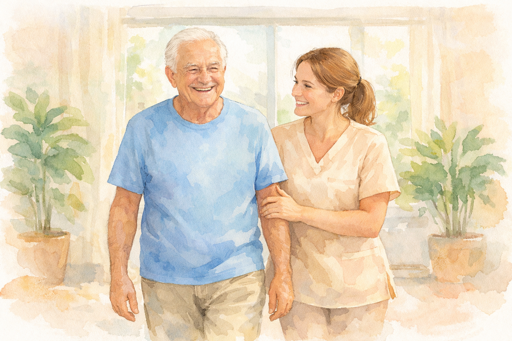

   💾 Saved to healthcare_illustration.png


In [12]:
# Step 2: Generate a calming illustration
print("\n🎨 Step 2/4: Generating comforting illustration...")

healthcare_image_prompt = """A warm, calming illustration of a senior patient smiling
and walking confidently with a physical therapist in a bright, modern rehabilitation room.
Soft pastel colors, gentle natural light through large windows, green plants visible.
Watercolor illustration style, soothing and optimistic mood, no medical equipment visible,
no needles or clinical elements. Professional healthcare marketing quality."""

healthcare_image = generate_image(
    prompt=healthcare_image_prompt,
    size="1536x1024",      # Landscape for waiting room display
    quality="medium"
)
print(f"   ✅ Generated in {healthcare_image['latency_sec']}s")
save_and_show_image(healthcare_image, filepath="healthcare_illustration.png")

In [16]:
# Step 3: Generate a short recovery-journey video
print("\n🎬 Step 3/4: Generating recovery journey video with Sora 2...")
print("   (This will take 1-5 minutes)\n")

healthcare_video = generate_video(
    prompt="""Slow, gentle camera pan across a bright, sunlit rehabilitation room.
A senior woman with silver hair smiles while doing light exercises with a kind physical therapist.
Warm pastel color palette, soft natural light, green plants in the background.
Calming, hopeful, and reassuring mood. Watercolor-style soft focus edges.
Camera slowly zooms in on the patient's confident smile.""",
    model="sora-2",
    seconds="8",
    size="1280x720",
    output_path="healthcare_recovery.mp4"
)

print(f"\n✅ Video generated in {healthcare_video['latency_sec']}s ({healthcare_video['size_mb']} MB)")
display(IPVideo(healthcare_video["path"], embed=True, width=640))


🎬 Step 3/4: Generating recovery journey video with Sora 2...
   (This will take 1-5 minutes)

   🚀 Starting Sora video job (sora-2, 8s, 1280x720)...
   📋 Job ID: video_699537fde09c8190abc4f838509a75510ccfc0ed8df54a46
   ⏳ Waiting for generation (this may take 1-5 minutes)...
   ⏳ [0s] Status: in_progress | Progress: 0%
   ⏳ [16s] Status: queued | Progress: 0%
   ⏳ [31s] Status: in_progress | Progress: 40%
   ⏳ [46s] Status: in_progress | Progress: 63%
   ⏳ [62s] Status: in_progress | Progress: 74%
   ⏳ [77s] Status: in_progress | Progress: 90%
   ⏳ [92s] Status: in_progress | Progress: 99%
   ⏳ [108s] Status: in_progress | Progress: 99%
   ⏳ [123s] Status: completed | Progress: 100%
   📥 Downloading MP4...

✅ Video generated in 125.21s (1.69 MB)


In [13]:
# Step 4: Generate audio guide
print("🔊 Step 4/4: Generating audio guide...")

healthcare_audio = generate_audio(
    text=patient_explanation,
    voice="marin",          # Warm, reassuring voice
    instructions="Speak slowly and clearly in a warm, reassuring, and empathetic tone. Like a kind nurse explaining to a patient.",
    output_path="patient_education_audio.mp3"
)
print(f"   ✅ Generated in {healthcare_audio['latency_sec']}s ({healthcare_audio['size_kb']} KB)")
print("\n🔊 Listen to the patient guide:")
display(Audio(healthcare_audio["path"], autoplay=False))

🔊 Step 4/4: Generating audio guide...


   ✅ Generated in 300.39s (84.0 KB)

🔊 Listen to the patient guide:


## 6. Reusable Multimodal Pipeline Function

Let's wrap the entire **5-modality workflow** into a single reusable function. This is the pattern you'd use in a production content automation system.

```
Input: Business brief (text)
  │
  ├── 📝 LLM → Product brief
  ├── 🎨 LLM → Image prompt → GPT Image 1.5 → Hero image
  ├── 🎬 LLM → Video prompt → Sora 2 → Promo video MP4
  ├── 🔊 LLM → Narration script → gpt-4o-mini-tts → Voiceover MP3
  └── 🔗 ffmpeg → Final video + voiceover MP4
```

In [14]:
def multimodal_campaign_pipeline(
    product_description,
    brief_system_prompt,
    image_size="1024x1024",
    video_seconds="8",
    video_size="1280x720",
    video_model="sora-2",
    tts_voice="nova",
    tts_instructions="Speak in a professional and engaging tone.",
    output_prefix="campaign"
):
    """
    End-to-end multimodal content pipeline.
    Input: product/service description
    Output: dict with brief, image, video, audio, final merged video + timing metadata
    """
    results = {"timings": {}}
    pipeline_start = time.time()

    # --- Step 1: Product Brief ---
    print("📝 Step 1/6: Generating product brief...")
    results["brief"], step_seconds = generate_text(
        system_prompt=brief_system_prompt,
        user_prompt=f"Create content for:\n{product_description}",
        temperature=0.7
    )
    results["timings"]["brief"] = step_seconds
    print(f"   ✅ {step_seconds}s")

    # --- Step 2: Image Prompt + Image ---
    print("🎨 Step 2/6: Generating hero image...")
    campaign_image_prompt, step_seconds = generate_text(
        system_prompt="""You are an expert at writing image generation prompts for OpenAI's GPT Image model.
Write a single detailed image generation prompt based on the given content.
Include subject, setting, lighting, colors, style, and composition.
Return ONLY the prompt text, nothing else.""",
        user_prompt=f"Write an image prompt for:\n{results['brief']}",
        temperature=0.8
    )
    results["image_prompt"] = campaign_image_prompt
    results["timings"]["image_prompt"] = step_seconds

    image_result = generate_image(campaign_image_prompt, size=image_size, quality="medium")
    results["image"] = image_result
    results["timings"]["image"] = image_result["latency_sec"]
    image_result["image"].save(f"{output_prefix}_hero.png")
    print(f"   ✅ {image_result['latency_sec']}s")

    # --- Step 3: Video Prompt + Video ---
    print(f"🎬 Step 3/6: Generating promo video ({video_model}, {video_seconds}s)...")
    campaign_video_prompt, step_seconds = generate_text(
        system_prompt=f"""You are an expert at writing video generation prompts for OpenAI's Sora model.
Write a single detailed video prompt for a {video_seconds}-second promotional video clip.
Describe: shot type, subject, action/motion, setting, lighting, camera movement, and mood.
Return ONLY the video prompt text, nothing else.""",
        user_prompt=f"Write a Sora video prompt for:\n{results['brief']}",
        temperature=0.8
    )
    results["video_prompt"] = campaign_video_prompt
    results["timings"]["video_prompt"] = step_seconds

    video_result = generate_video(campaign_video_prompt, model=video_model, seconds=video_seconds,
                         size=video_size, output_path=f"{output_prefix}_promo.mp4")
    results["video"] = video_result
    results["timings"]["video"] = video_result["latency_sec"]
    print(f"   ✅ {video_result['latency_sec']}s")

    # --- Step 4: Voiceover Script + Audio ---
    print("🔊 Step 4/6: Generating voiceover...")
    narration_script, script_seconds = generate_text(
        system_prompt=f"Condense the following into a {video_seconds}-second spoken narration (under 30 words). Make it engaging and clear. Return ONLY the narration text.",
        user_prompt=results["brief"],
        temperature=0.7
    )
    results["narration_script"] = narration_script
    results["timings"]["narration_script"] = script_seconds

    audio = generate_audio(narration_script, voice=tts_voice, instructions=tts_instructions,
                           output_path=f"{output_prefix}_voiceover.mp3")
    results["audio"] = audio
    results["timings"]["audio"] = audio["latency_sec"]
    print(f"   ✅ {audio['latency_sec']}s")

    # --- Step 5: Merge Video + Voiceover ---
    print("🔗 Step 5/6: Merging video + voiceover...")
    merged = merge_video_audio(
        video_path=video_result["path"],
        audio_path=audio["path"],
        output_path=f"{output_prefix}_final.mp4"
    )
    results["final_video"] = merged
    results["timings"]["merge"] = merged["latency_sec"]
    print(f"   ✅ {merged['latency_sec']}s")

    # --- Done ---
    results["timings"]["total"] = round(time.time() - pipeline_start, 2)
    print(f"\n🏁 Pipeline complete in {results['timings']['total']}s")

    return results


def display_campaign_results(results):
    """Display all generated assets in the notebook."""
    print("\n" + "=" * 60)
    print("📦 CAMPAIGN ASSET PACKAGE")
    print("=" * 60)

    print("\n📝 BRIEF:")
    print("-" * 40)
    print(results["brief"])

    print("\n🎨 HERO IMAGE:")
    print("-" * 40)
    thumbnail_image = results["image"]["image"].copy()
    thumbnail_image.thumbnail((512, 512))
    display(thumbnail_image)

    print("\n🎬 PROMO VIDEO (raw):")
    print("-" * 40)
    display(IPVideo(results["video"]["path"], embed=True, width=480))

    print("\n🔊 VOICEOVER:")
    print("-" * 40)
    print(f"Script: {results['narration_script']}")
    display(Audio(results["audio"]["path"], autoplay=False))

    print("\n🎬 FINAL VIDEO (with voiceover):")
    print("-" * 40)
    display(IPVideo(results["final_video"]["path"], embed=True, width=480))

    print("\n⏱️ TIMING BREAKDOWN:")
    print("-" * 40)
    for step, step_seconds in results["timings"].items():
        if step != "total":
            print(f"  {step:<20s}: {step_seconds:.1f}s")
    print(f"  {'TOTAL':<20s}: {results['timings']['total']:.1f}s")

print("Pipeline function defined ✅")

Pipeline function defined ✅


## 7. Scenario 3 — Financial Services: Savings Account Promo

### Business Context
A retail bank is launching a **new high-yield savings account** and needs a full digital campaign package — social media image, short video ad, and voiceover — all from a single product description.

> **⏱️ Note:** This pipeline includes video generation, so it will take 2-6 minutes total.

In [19]:
# --- Run full pipeline for banking product ---
banking_results = multimodal_campaign_pipeline(
    product_description="""
    Product: "SmartSave Pro" — High-Yield Digital Savings Account
    - 5.2% APY, no minimum balance, no monthly fees
    - Automatic round-up savings from debit card purchases
    - AI-powered savings goals and spending insights
    - FDIC insured up to $250,000
    - Target: Young professionals aged 25-35
    - Channel: Instagram + LinkedIn ads
    """,
    brief_system_prompt="""You are a fintech marketing strategist. Generate a concise
product brief with: Value Proposition, Key Messages (3 bullets), Target Audience,
Suggested Campaign Tagline. Keep under 180 words.""",
    image_size="1024x1024",
    video_seconds="8",
    video_model="sora-2",
    tts_voice="ash",
    tts_instructions="Speak in a confident, modern, and trustworthy tone. Like a fintech brand video.",
    output_prefix="banking"
)

📝 Step 1/6: Generating product brief...
   ✅ 2.62s
🎨 Step 2/6: Generating hero image...
   ✅ 17.66s
🎬 Step 3/6: Generating promo video (sora-2, 8s)...
   🚀 Starting Sora video job (sora-2, 8s, 1280x720)...
   📋 Job ID: video_6995389d165c8190bfbff9b32b9bdfc70016bc89c0c9abd2
   ⏳ Waiting for generation (this may take 1-5 minutes)...
   ⏳ [0s] Status: in_progress | Progress: 0%
   ⏳ [16s] Status: queued | Progress: 0%
   ⏳ [31s] Status: in_progress | Progress: 52%
   ⏳ [46s] Status: in_progress | Progress: 64%
   ⏳ [62s] Status: in_progress | Progress: 84%
   ⏳ [77s] Status: in_progress | Progress: 90%
   ⏳ [92s] Status: in_progress | Progress: 99%
   ⏳ [108s] Status: completed | Progress: 100%
   📥 Downloading MP4...
   ✅ 109.72s
🔊 Step 4/6: Generating voiceover...
   ✅ 3.46s
🔗 Step 5/6: Merging video + voiceover...
   ✅ 0.49s

🏁 Pipeline complete in 139.81s


In [20]:
# Display all banking campaign assets
display_campaign_results(banking_results)

Output hidden; open in https://colab.research.google.com to view.

## 8. Scenario 4 — Insurance: Family Health Plan Campaign

### Business Context
A health insurance company is launching a **family health plan** during open enrollment. They need a complete asset package: hero image, short video ad, and voiceover for a cross-channel campaign.

In [22]:
# --- Run full pipeline for insurance product ---
insurance_results = multimodal_campaign_pipeline(
    product_description="""
    Product: "FamilyShield 360" — Comprehensive Family Health Insurance Plan
    - Covers the entire family (2 adults + up to 4 children) under one plan
    - Zero co-pay for preventive care and annual check-ups
    - Includes dental, vision, and mental health coverage
    - Telehealth consultations included at no extra cost
    - Premium: Starting at $450/month
    - Target: Families with children, ages 30-50
    - Season: Open enrollment period
    """,
    brief_system_prompt="""You are a health insurance marketing specialist. Generate a concise
product brief with: Positioning Statement, Key Benefits (3 bullets), Target Family Profile,
Suggested Campaign Tagline. Keep under 180 words. Tone: warm, reassuring, family-focused.""",
    image_size="1536x1024",    # Landscape for email headers
    video_seconds="8",
    video_model="sora-2",
    tts_voice="coral",
    tts_instructions="Speak in a warm, reassuring, and family-friendly tone. Like a trusted advisor.",
    output_prefix="insurance"
)

📝 Step 1/6: Generating product brief...
   ✅ 2.28s
🎨 Step 2/6: Generating hero image...
   ✅ 29.99s
🎬 Step 3/6: Generating promo video (sora-2, 8s)...
   🚀 Starting Sora video job (sora-2, 8s, 1280x720)...
   📋 Job ID: video_699539edffcc819093c09caa3df483790441395a6521118e
   ⏳ Waiting for generation (this may take 1-5 minutes)...
   ⏳ [0s] Status: in_progress | Progress: 0%
   ⏳ [16s] Status: queued | Progress: 0%
   ⏳ [31s] Status: in_progress | Progress: 40%
   ⏳ [46s] Status: in_progress | Progress: 51%
   ⏳ [62s] Status: in_progress | Progress: 75%
   ⏳ [77s] Status: in_progress | Progress: 85%
   ⏳ [92s] Status: in_progress | Progress: 99%
   ⏳ [108s] Status: in_progress | Progress: 99%
   ⏳ [123s] Status: completed | Progress: 100%
   📥 Downloading MP4...
   ✅ 124.96s
🔊 Step 4/6: Generating voiceover...
   ✅ 2.39s
🔗 Step 5/6: Merging video + voiceover...
   ✅ 0.33s

🏁 Pipeline complete in 166.91s


In [ ]:
# Display all insurance campaign assets
display_campaign_results(insurance_results)

## 9. Bonus — Video Remix (Iterating on Generated Videos)

Sora supports **remixing** — taking an existing completed video and applying targeted changes without regenerating from scratch. This is like image editing, but for video.

Use cases:
- Change the color palette for A/B testing
- Adjust the mood (e.g., make it more energetic)
- Add/remove visual elements

> **Note:** Remix works best with **single, well-defined changes** — smaller edits preserve more of the original.

In [ ]:
# --- Remix the banking video with a new color palette ---
# Use the video_id from the banking pipeline
banking_video_id = banking_results["video"]["video_id"]

print(f"🎬 Remixing banking video (ID: {banking_video_id})...")
print("   Changing color palette to warm sunset tones...\n")

# Submit the remix job
remix_payload = {"prompt": "Shift the overall color palette to warm sunset tones — golden amber, soft coral, and deep burgundy. Keep everything else the same."}
remix_response = requests.post(
    f"{API_BASE}/videos/{banking_video_id}/remix",
    headers=AUTH_HEADERS,
    json=remix_payload
)
remix_response.raise_for_status()
remix_job = remix_response.json()
remix_id = remix_job["id"]
print(f"   📋 Remix Job ID: {remix_id}")

# Poll until complete
print("   ⏳ Waiting for remix generation...")
final_remix = poll_video_status(remix_id)

# Download
remix_download = download_video(remix_id, "banking_remix_sunset.mp4")
print(f"\n✅ Remix complete ({remix_download['size_mb']} MB)")
print("\n🎬 Original vs Remix:")
print("Original:")
display(IPVideo(banking_results["video"]["path"], embed=True, width=480))
print("\nRemix (sunset palette):")
display(IPVideo("banking_remix_sunset.mp4", embed=True, width=480))

## 10. Cost & Timing Analysis

In [15]:
# --- Cost estimation for one full campaign package ---
cost_estimates = {
    "Text — gpt-4.1-mini (4 LLM calls)": {"estimate_usd": 0.004, "note": "~4 calls × ~500 tokens each"},
    "Image — GPT Image 1.5 (medium)":    {"estimate_usd": 0.020, "note": "~1,056 output tokens"},
    "Video — Sora 2 (8s, 720p)":         {"estimate_usd": 0.480, "note": "8 seconds at $0.06/s"},
    "Audio — gpt-4o-mini-tts":           {"estimate_usd": 0.005, "note": "~30-word narration"},
}

print("💰 ESTIMATED COST PER CAMPAIGN PACKAGE (with video)")
print("=" * 60)
total = 0
for component, info in cost_estimates.items():
    print(f"  {component:<42s} ${info['estimate_usd']:.3f}  ({info['note']})")
    total += info["estimate_usd"]
print("-" * 60)
print(f"  {'TOTAL':<42s} ${total:.3f}")
print(f"\n📊 Video dominates the cost (~94%). Without video: ~$0.03/package")
print("   Compare: Human-produced campaign with video typically costs $2,000-$20,000+")

# Actual timing from our runs
print(f"\n⏱️ ACTUAL PIPELINE TIMES:")
# The two pipeline runs above need video access; report whichever of them ran.
for name, results in [("Banking", globals().get("banking_results")),
                      ("Insurance", globals().get("insurance_results"))]:
    if results:
        step_seconds = results["timings"]
        video_share_percent = round(step_seconds.get("video", 0) / step_seconds["total"] * 100)
        print(f"  {name:<12s}: {step_seconds['total']:.0f}s total (video: {step_seconds.get('video', 0):.0f}s = {video_share_percent}% of time)")

💰 ESTIMATED COST PER CAMPAIGN PACKAGE (with video)
  Text — gpt-4.1-mini (4 LLM calls)          $0.004  (~4 calls × ~500 tokens each)
  Image — GPT Image 1.5 (medium)             $0.020  (~1,056 output tokens)
  Video — Sora 2 (8s, 720p)                  $0.480  (8 seconds at $0.06/s)
  Audio — gpt-4o-mini-tts                    $0.005  (~30-word narration)
------------------------------------------------------------
  TOTAL                                      $0.509

📊 Video dominates the cost (~94%). Without video: ~$0.03/package
   Compare: Human-produced campaign with video typically costs $2,000-$20,000+

⏱️ ACTUAL PIPELINE TIMES:


## 11. Production Architecture Patterns

### End-to-End Pipeline Architecture

```
┌──────────────┐     ┌─────────────────────────────────┐     ┌───────────────┐
│  Product DB   │────▶│      Campaign Engine             │────▶│  Asset Store   │
│  (input data) │     │                                   │     │  (S3 / CDN)    │
└──────────────┘     │  📝 Text (gpt-4.1-mini)          │     └───────────────┘
                     │  🎨 Image (GPT Image 1.5)         │
                     │  🎬 Video (Sora 2) ← async job    │
                     │  🔊 Audio (gpt-4o-mini-tts)       │
                     │  🔗 Merge (ffmpeg)                 │
                     └─────────────────────────────────┘
```

### Key Production Considerations

| Concern | Solution |
|---------|----------|
| **Video latency** | Submit video job first (longest step), then generate image + audio **in parallel** while video renders |
| **Cost at scale** | Use `sora-2` for drafts, `sora-2-pro` only for final renders. Use GPT Image `low` quality for thumbnails |
| **Quality control** | Add human review before publishing; use content moderation APIs |
| **Async handling** | Use webhooks (`video.completed` event) instead of polling in production |
| **Brand consistency** | Include brand guidelines in system prompts; maintain a prompt template library |
| **Compliance** | Financial/healthcare video content needs legal review — GenAI produces drafts, not final copy |
| **Storage** | Sora download URLs expire after 1 hour — copy to your own S3/GCS immediately |

---

## 12. Conclusion & Next Steps

### What We Covered

| Step | Technology | Purpose |
|------|-----------|---------|
| **Text generation** | `gpt-4.1-mini` | Product briefs, ad scripts, optimized prompts |
| **Prompt chaining** | LLM → LLM | Generating optimized prompts for image and video models |
| **Image generation** | `gpt-image-1.5` | Hero images from LLM-crafted prompts |
| **Video generation** | `sora-2` | Promotional video clips (async job + poll + download) |
| **Video remix** | `sora-2` | Iterating on videos with targeted changes |
| **Text-to-speech** | `gpt-4o-mini-tts` | Voiceovers with voice/style control |
| **Video + audio merge** | `ffmpeg` | Combining video with voiceover narration |
| **Pipeline design** | Functional composition | Reusable, modular multimodal workflow |

### Scenarios Demonstrated

| Scenario | Industry | Assets Produced |
|----------|----------|----------------|
| Herbal Tea Launch | E-commerce | Brief + hero image + promo video + voiceover + final ad |
| Patient Education | Healthcare | Explanation + illustration + recovery video + audio guide |
| Savings Account Promo | Banking/Fintech | Full pipeline: brief → image → video → VO → merged |
| Family Health Plan | Insurance | Full pipeline: brief → image → video → VO → merged |

### Try on Your Own
1. Use `sora-2-pro` instead of `sora-2` and compare the video quality difference
2. Try **image-to-video** — generate a hero image first, then use it as `input_reference` for Sora
3. Generate assets in **multiple languages** — translate the brief, then generate localized prompts and TTS
4. Implement **parallel execution** with `asyncio` — start the video job first, generate image + audio while waiting
5. Build a **Gradio or Streamlit** interface where users input a product description and get a downloadable asset package

---

**This completes Module 1's take-home labs.**

Next up: **Module 2 — LangChain Deep Dive & LLM Reliability**. 🐍